# Лабораторная работа №2

**Выполнили:**
> Галеев Егор Вячеславович, J3119, 505106

> Образцов Максим Евгеньевич, J3119, 466930

### Цель работы 
Исследовать методы вычисления сингулярного разложения матриц на примере обра-
ботки изображений, сравнить эффективность степенного метода и метода вращений
Якоби, изучить применение усеченного SVD для сжатия данных.

## 1. Краткие теоретические сведения

### Сингулярное разложение (SVD)
Сингулярное разложение (Singular Value Decomposition) - это метод факторизации произвольной прямоугольной матрицы. Любую вещественную матрицу $A$ размера $m \times n$ можно представить в виде произведения трех матриц:
$$A = U \Sigma V^T$$
где:
* $U$ - ортогональная матрица размера $m \times m$, столбцы которой называются левыми сингулярными векторами.
* $V$ - ортогональная матрица размера $n \times n$, столбцы которой называются правыми сингулярными векторами.
* $\Sigma$ - диагональная матрица размера $m \times n$, на главной диагонали которой располагаются неотрицательные сингулярные числа $\sigma_i$. Обычно они упорядочены по убыванию: $\sigma_1 \geq \sigma_2 \geq \dots \geq \sigma_r > 0$.

### Степенной метод
Степенной метод - это базовый итерационный алгоритм для нахождения доминирующего собственного значения и соответствующего ему собственного вектора матрицы. Применительно к вычислению SVD матрицы $A$, метод работает с симметричными матрицами вида $A^T A$ (для поиска правых векторов) или $A A^T$ (для левых). 

Итерационный процесс поиска первого (правого) сингулярного вектора $v_1$ выглядит так:
$$v_{k+1} = \frac{A^T A v_k}{||A^T A v_k||}$$
Достигнув сходимости, мы получаем наибольшее сингулярное число как $\sigma_1 = ||A v_1||$. Чтобы найти последующие компоненты разложения, применяется процедура «исчерпывания» (deflation): из исходной матрицы вычитается проекция на найденный вектор ($A_{new} = A - \sigma_1 u_1 v_1^T$), после чего процесс повторяется для поиска следующего максимума. Точность разложения напрямую зависит от числа итераций степенного метода.

### Метод вращений Якоби
Метод вращений Якоби - это алгоритм, используемый для нахождения собственных значений симметричной матрицы путём приведения её к диагональному виду. Алгоритм заключается в последовательном умножении исходной матрицы $M = A^T A$ на ортогональные матрицы вращения (матрицы Гивенса).

На каждой итерации выбирается наибольший по модулю внедиагональный элемент матрицы, и строится матрица вращения $J$, которая обнуляет этот элемент:
$$M_{k+1} = J_k^T M_k J_k$$
Процесс продолжается до тех пор, пока все внедиагональные элементы не станут меньше заданного малого порога $\varepsilon$. На диагонали результирующей матрицы остаются собственные значения (квадраты сингулярных чисел матрицы $A$), а произведение всех матриц вращения образует матрицу правых сингулярных векторов $V$.


### Применение SVD для обработки изображений
Цифровое изображение можно представить как двумерный массив пикселей, а цветное - как тензор из трех матриц (каналы Red, Green, Blue). В таком представлении SVD можно применять для сжатия изображений, устранения шума или выделения контуров.

Для сжатия используется так называемое усеченное сингулярное разложение (Truncated SVD). Идея состоит в том, чтобы сохранить в разложении только $k$ старших сингулярных чисел, отбросив младшие ($k \ll \min(n, m)$):
$$A_k = U_k \Sigma_k V_k^T$$
Поскольку сингулярные числа упорядочены по убыванию своей значимости, первые несколько компонент несут в себе основную массу изображения (крупные детали, цвета), в то время как младшие компоненты отвечают за мелкий шум и незначительные нюансы. Заменив исходную матрицу $A$ на матрицу меньшего ранга $A_k$, мы получаем приемлемое визуальное качество восстановленного изображения, но при этом существенно сокращаем объем памяти для хранения данных (повышаем степень сжатия), поскольку хранить нужно лишь усеченные версии матриц $U$, $\Sigma$ и $V$.



## 2. Ход работы

Для выполнения лабораторной работы было выбрано изображение белого медведя на фоне заснеженного пейзажа. Фотография имеет нейтральный характер и удовлетворяет всем исходным требованиям: формат файла - JPEG, разрешение соответствует требуемому ($1600 \times 900$ пикселей). 

Изображение подходит для исследования алгоритмов сжатия на основе сингулярного разложения (SVD). В нем присутствуют как области с плавными цветовыми переходами и низкочастотными изменениями (белый снег на переднем плане, темно-синий фон), так и участки с высокой детализацией и текстурностью (шерсть медведя, свечение и рельеф снега). Это позволит наглядно оценить визуальные потери качества при использовании усеченного SVD и проанализировать, как алгоритм работает в различных цветовых каналах (R, G, B).




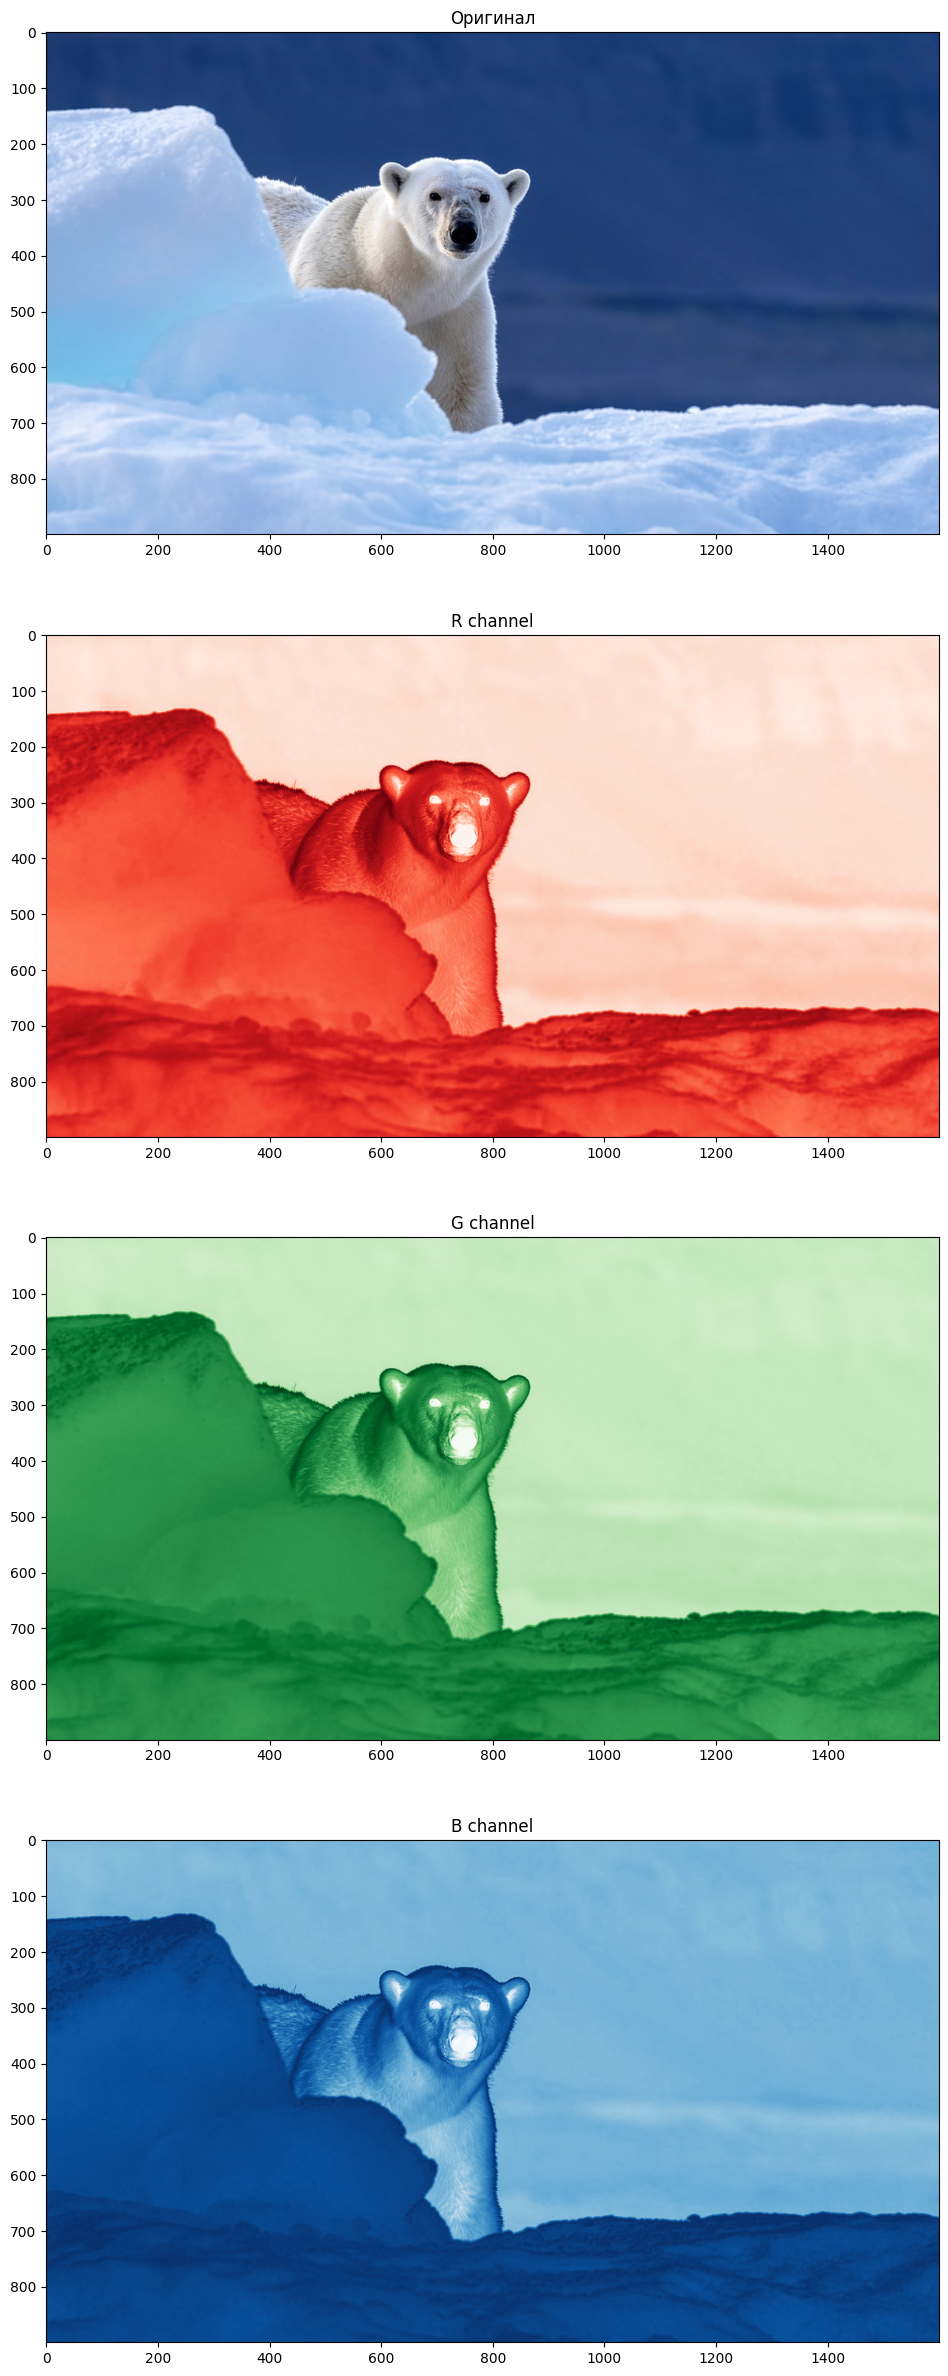

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import cv2
import time

# 1. Преобразование изображения
def load_and_split_image(path):
    
    # Загрузка изображения
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Изображение по адресу {path} не найдено")
    
    # Конвертация из BGR в RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 

    # Проверка размера
    height, width, channels = img.shape
    if height < 640 or width < 640:
        raise ValueError("Размер изображения должен быть не менее 640x640 пикселей")

    # Нормализуем в диапазон [0, 1]
    img_normalized = img.astype(np.float64) / 255.0

    R = img_normalized[:,:,0]
    G = img_normalized[:,:,1]
    B = img_normalized[:,:,2]

    return img_normalized, R, G, B

# Загружаем данные
img_original, R, G, B = load_and_split_image('image.jpg')

# Визуализация
plt.figure(figsize=(30, 30))
plt.subplot(4, 1, 1); plt.imshow(img_original); plt.title("Оригинал")
plt.subplot(4, 1, 2); plt.imshow(R, cmap='Reds'); plt.title("R channel")
plt.subplot(4, 1, 3); plt.imshow(G, cmap='Greens'); plt.title("G channel")
plt.subplot(4, 1, 4); plt.imshow(B, cmap='Blues'); plt.title("B channel")
plt.show()

    

In [23]:
# 2. Сингулярное разложение степенным методом
def power_iteration_svd(A, k=50, iter_num=100):
    
    # Размеры матрицы
    m, n = A.shape

    # Инициализируем матрицы по заданным размерам
    U = np.zeros((m, k))
    V = np.zeros((n, k))
    S = np.zeros(k)

    A_def = A.copy()
    for i in range(k):
        # Случайное приближение вектора
        np.random.seed(42+i)
        v = np.random.randn(n)
        v = v / np.linalg.norm(v)

        for _ in range(iter_num):
            # u = A * v
            u = A_def @ v
            u_norm = np.linalg.norm(u)
            if u_norm == 0:
                break
            u = u / u_norm

            v = A_def.T @ u
            v_norm = np.linalg.norm(v)
            if v_norm == 0:
                break
            v = v / v_norm
        
        # Вычисление сингулярного значения
        sigma = u.T @ A_def @ v

        # Обработка отрицательных сингулярных значений
        if sigma < 0:
            sigma = -sigma
            v = -v
        
        U[:, i] = u
        V[:, i] = v
        S[i] = sigma

        A_def = A_def - sigma * np.outer(u, v)

    return U, S, V.T


# Анализ для разного числа итераций 
iterations_list = [10, 50, 100]
k_components = 50 # количество компонент

print(f"{'Канал':<6} | {'Итерации':<10} | {'Норма разности ||A - U*S*V^T||':<30}")
print("-" * 50)

for channel_name, channel_matrix in zip(['R', 'G', 'B'], [R, G, B]):
    for iters in iterations_list:
        U, S, Vt = power_iteration_svd(channel_matrix, k=k_components, iter_num=iters)
        
        # Восстановление матрицы (для проверки нормы разности) [cite: 24, 25]
        A_reconstructed = U @ np.diag(S) @ Vt
        
        # Норма разности считается между исходной матрицей и восстановленной (усеченной)
        # Поскольку мы искали только k компонент, норма разности покажет ошибку аппроксимации
        norm_diff = np.linalg.norm(channel_matrix - A_reconstructed, ord='fro')
        
        print(f"{channel_name:<6} | {iters:<10} | {norm_diff:<30.4f}")

Канал  | Итерации   | Норма разности ||A - U*S*V^T||
--------------------------------------------------
R      | 10         | 19.7211                       
R      | 50         | 19.6637                       
R      | 100        | 19.6637                       
G      | 10         | 18.1262                       
G      | 50         | 18.1075                       
G      | 100        | 18.1074                       
B      | 10         | 16.6604                       
B      | 50         | 16.6506                       
B      | 100        | 16.6505                       


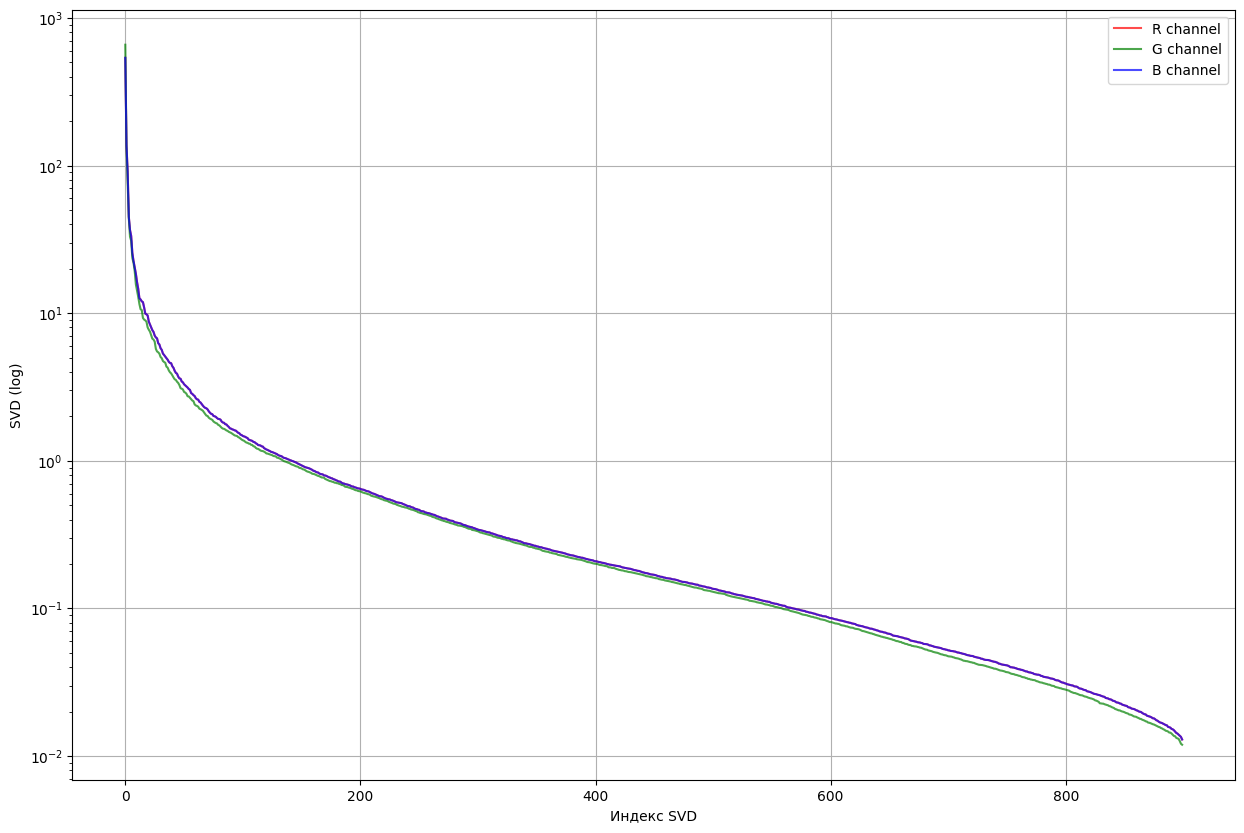

In [29]:
# 3. Анализ Сингулярных чисел и усеченное SVD

# Полные сингулярные числа для каждого канала
U_r, S_r, Vt_r = np.linalg.svd(R, full_matrices=False)
U_g, S_g, Vt_g = np.linalg.svd(G, full_matrices=False)
U_b, S_b, Vt_b = np.linalg.svd(B, full_matrices=False)

# График зависиости порядкового номера от SVD
plt.figure(figsize=(15, 10))
plt.plot(S_r, label='R channel', color='red', alpha=0.7)
plt.plot(S_g, label='G channel', color='green', alpha=0.7)
plt.plot(S_r, label='B channel', color='blue', alpha=0.7)
plt.yscale('log')
plt.grid()
plt.title
plt.xlabel('Индекс SVD')
plt.ylabel('SVD (log)')
plt.legend()
plt.show()


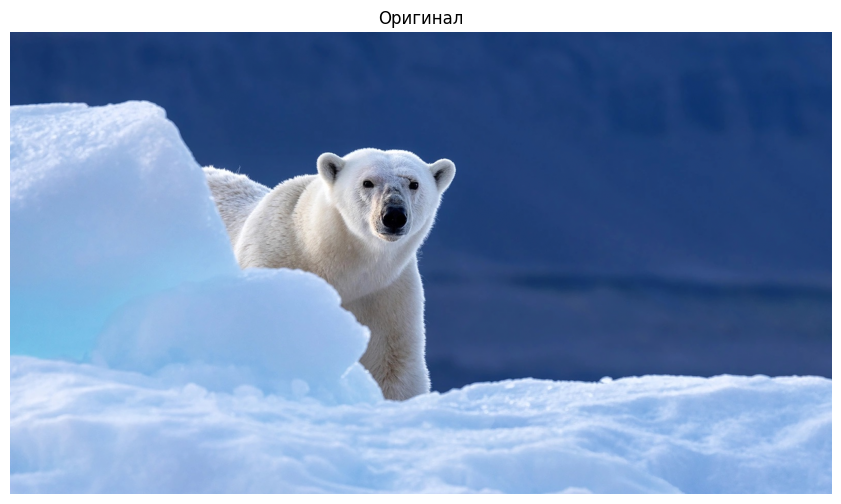

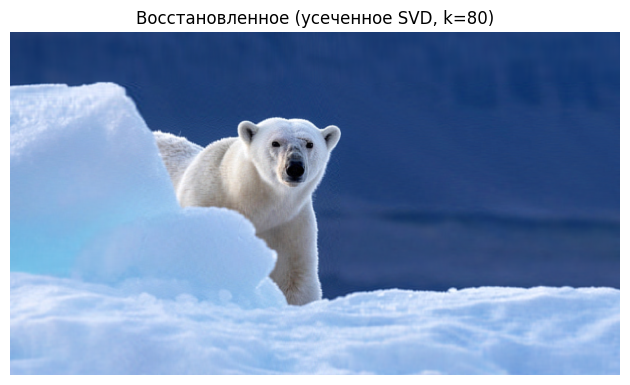

In [ ]:

# Реализация усеченного разложения
# Из графика следует, что основная энергия сосредоточена в первых 50-80 числах

k_optimal = 80

def truncated_svd(U, S, Vt, k):
    U_k = U[:, :k]
    S_k = np.diag(S[:k])
    Vt_k = Vt[:k, :]
    return np.clip(U_k @ S_k @ Vt_k, 0, 1)

R_k = truncated_svd(U_r, S_r, Vt_r, k_optimal)
G_k = truncated_svd(U_g, S_g, Vt_g, k_optimal)
B_k = truncated_svd(U_b, S_b, Vt_b, k_optimal)

img_reconstructed = np.stack((R_k, G_k, B_k), axis=-1)

# Визуализация результатов
plt.figure(figsize=(12, 6))
plt.plot(121)
plt.imshow(img_original)
plt.title("Оригинал")
plt.axis('off')
plt.show()
plt.plot()
plt.imshow(img_reconstructed)
plt.title(f"Восстановленное (усеченное SVD, k={k_optimal})")
plt.axis('off')
plt.tight_layout()
plt.show()